# Deterministic CVHT Models — PCR, Random Forest, XGBoost

This ports the original R modeling step (`02-Deterministic_Models.R`) to
Python. For each lake independently:

1. Impute missing predictors with the median, drop zero-variance columns,
   standardize, and reduce to **3 principal components**.
2. Fit three regressors — linear regression on the components (PCR),
   Random Forest, and XGBoost.
3. Evaluate with **leave-one-out cross-validation (LOOCV)**: refit the whole
   pipeline (including PCA) with one lake-year held out, predict it, repeat
   for every year. This avoids leaking information between the training and
   held-out fold and matches the original R loop.

One deliberate change from the R script: tree count is 300 instead of 1000
(both RF and XGBoost) — for ~40 rows and 3 PCA features, predictions are
essentially unchanged past a few hundred trees, and it keeps a 5-lake ×
3-model × LOOCV grid (215 folds) fast to re-run from scratch.


In [1]:
import sys
sys.path.append("..")
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.io as pio

from src.data import load_master_table, LAKE_NAMES
from src.models import run_all_models, score_table
from src.viz import set_style, LAKE_COLORS, MODEL_COLORS

set_style()
pio.renderers.default = "png"

df = load_master_table()
t0 = time.time()
export_all = run_all_models(df)
print(f"Ran LOOCV for {export_all['lake_id'].nunique()} lakes x 3 models in {time.time() - t0:.1f}s")
export_all.to_csv("../outputs/cvht_obs_preds_all_models_python.csv", index=False)
export_all.head()


Ran LOOCV for 5 lakes x 3 models in 96.0s


,lake_id,lake_name,year,observed_cvht,pred_pcr,pred_rf,pred_xgb
0,AL,Allequash,1981,0.0,4.414422,4.815155,5.423338
1,AL,Allequash,1982,6.0,3.394299,2.772975,1.017403
2,AL,Allequash,1983,3.5,3.582006,4.690297,3.298497
3,AL,Allequash,1984,3.5,4.520986,6.392641,8.345614
4,AL,Allequash,1985,7.5,3.783434,5.852820,8.704117


## Model performance by lake

In [2]:
scores = score_table(export_all)
scores.to_csv("../outputs/cvht_model_scores_python.csv", index=False)
scores.pivot(index="lake_id", columns="model", values="r_squared").round(3)


model,PCR,Random Forest,XGBoost
lake_id,,,
AL,-0.136,-0.113,-0.537
BM,0.331,0.171,-0.256
CR,-0.028,-0.013,-0.136
SP,0.081,0.003,-0.325
TR,0.299,0.202,-0.148


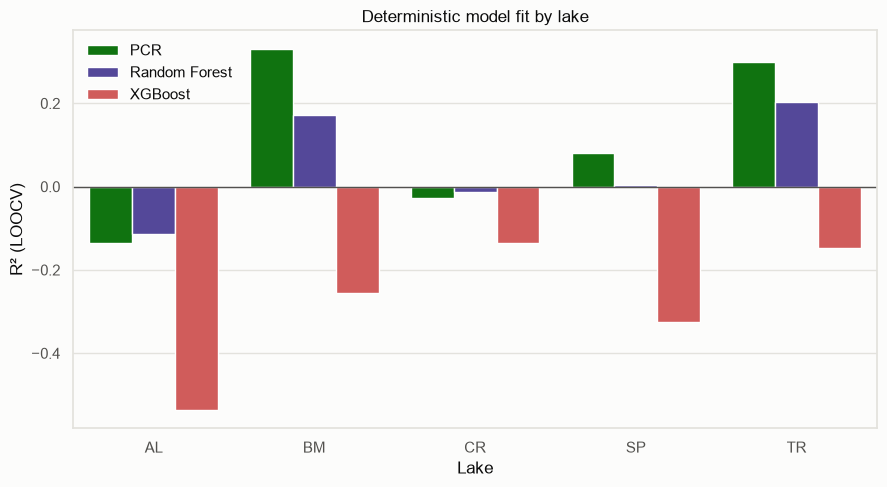

In [3]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(
    data=scores, x="lake_id", y="r_squared", hue="model",
    palette=MODEL_COLORS, ax=ax,
)
ax.axhline(0, color="#52514e", linewidth=1)
ax.set_xlabel("Lake")
ax.set_ylabel("R\u00b2 (LOOCV)")
ax.set_title("Deterministic model fit by lake")
ax.legend(title=None, frameon=False)
fig.tight_layout()
fig.savefig("../figures/02_model_r2_by_lake.png", dpi=150)
plt.show()


## Observed vs. predicted CVHT, by lake

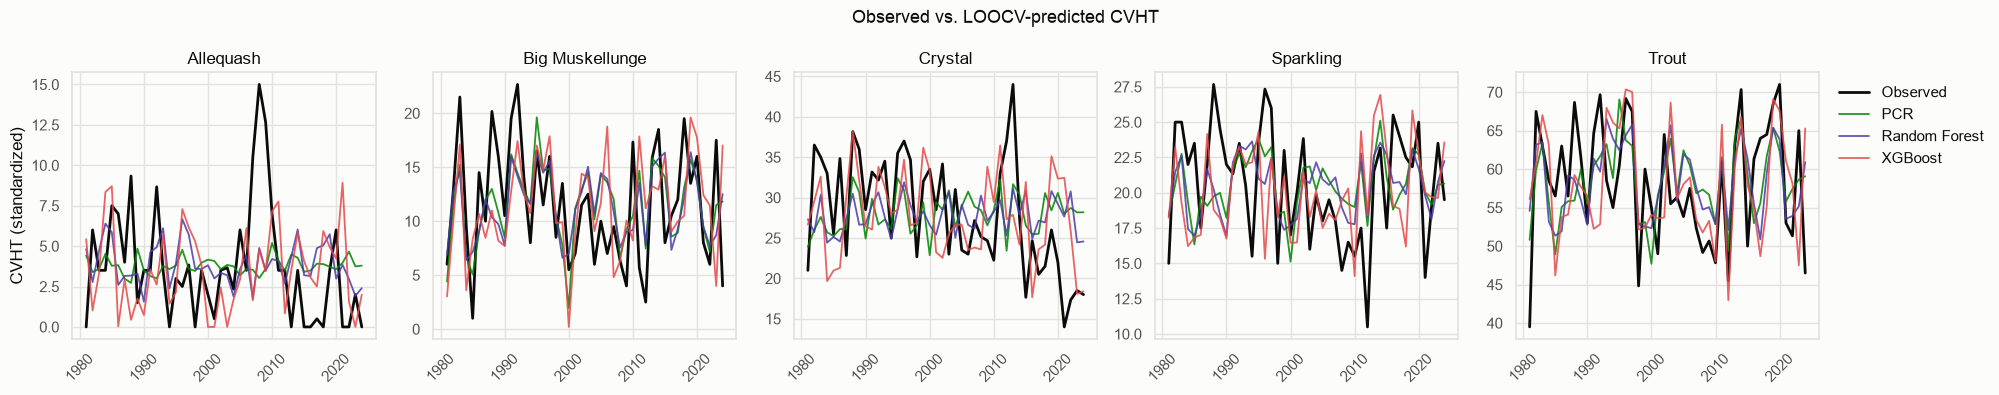

In [4]:
lakes = export_all["lake_id"].unique()
fig, axes = plt.subplots(1, len(lakes), figsize=(4 * len(lakes), 4), sharey=False)
for ax, lake_id in zip(axes, lakes):
    g = export_all[export_all["lake_id"] == lake_id].sort_values("year")
    ax.plot(g["year"], g["observed_cvht"], color="#0b0b0b", linewidth=2, label="Observed")
    for col, model_name in [("pred_pcr", "PCR"), ("pred_rf", "Random Forest"), ("pred_xgb", "XGBoost")]:
        ax.plot(g["year"], g[col], color=MODEL_COLORS[model_name], linewidth=1.3, alpha=0.85, label=model_name)
    ax.set_title(LAKE_NAMES[lake_id])
    ax.tick_params(axis="x", rotation=45)
axes[0].set_ylabel("CVHT (standardized)")
axes[-1].legend(loc="upper left", bbox_to_anchor=(1.02, 1), frameon=False)
fig.suptitle("Observed vs. LOOCV-predicted CVHT")
fig.tight_layout()
fig.savefig("../figures/02_observed_vs_predicted.png", dpi=150, bbox_inches="tight")
plt.show()


Interactive version, one lake at a time (use the dropdown-like legend to isolate a model).

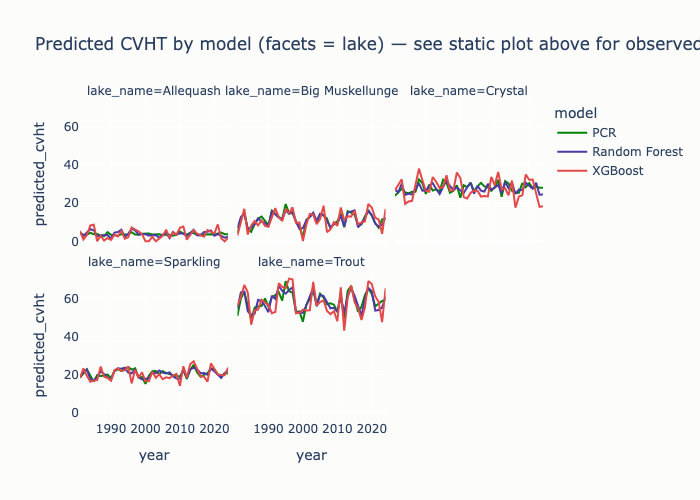

In [5]:
long = export_all.melt(
    id_vars=["lake_id", "lake_name", "year", "observed_cvht"],
    value_vars=["pred_pcr", "pred_rf", "pred_xgb"],
    var_name="model", value_name="predicted_cvht",
).replace({"model": {"pred_pcr": "PCR", "pred_rf": "Random Forest", "pred_xgb": "XGBoost"}})

fig = px.line(
    long, x="year", y="predicted_cvht", color="model", facet_col="lake_name", facet_col_wrap=3,
    color_discrete_map=MODEL_COLORS, title="Predicted CVHT by model (facets = lake) — see static plot above for observed overlay",
)
fig.update_layout(plot_bgcolor="#fcfcfb", paper_bgcolor="#fcfcfb")
fig.show()
